# 🎬 Netflix Content Analysis
## Exploring Content Types, Genres, Ratings, Duration, and Growth Trends

**Author:** Ahmed Balogun  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** `netflix_titles.csv`

### Project Goal
This notebook analyzes Netflix's catalog of movies and TV shows to uncover patterns in content distribution, genre popularity, ratings, duration, and catalog growth over time.

### Business Relevance
Understanding these trends can help a streaming platform:
- identify dominant content categories,
- track content expansion over time,
- understand audience targeting through ratings,
- and spot opportunities for international or genre-specific growth.


## 1. Import Libraries
We begin by importing the Python libraries used for data cleaning, analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 2. Load the Dataset
The dataset is loaded into a pandas DataFrame and previewed to understand its structure.

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Data Overview
Before cleaning, we inspect the dataset structure, data types, and missing values.

In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (8807, 12)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

## 4. Data Cleaning
In this section, we:
- handle missing values,
- convert date fields,
- create a `year_added` column,
- clean movie duration values,
- and prepare genre and country fields for analysis.

In [6]:
df = df.copy()

# Handle missing values
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")

# Convert date columns
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

# Keep a clean version of listed genres
df["listed_in_clean"] = df["listed_in"].str.split(", ")

# Create a clean movie-only dataframe for duration analysis
df_movies = df[df["type"] == "Movie"].copy()
df_movies["duration_minutes"] = (
    df_movies["duration"]
    .str.replace(" min", "", regex=False)
)
df_movies["duration_minutes"] = pd.to_numeric(df_movies["duration_minutes"], errors="coerce")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,listed_in_clean
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,[Documentaries]
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,"[International TV Shows, TV Dramas, TV Mysteries]"
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,"[Crime TV Shows, International TV Shows, TV Ac..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,"[Docuseries, Reality TV]"
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,"[International TV Shows, Romantic TV Shows, TV..."


## 5. Content Type Distribution
This chart compares the number of Movies and TV Shows available on Netflix.

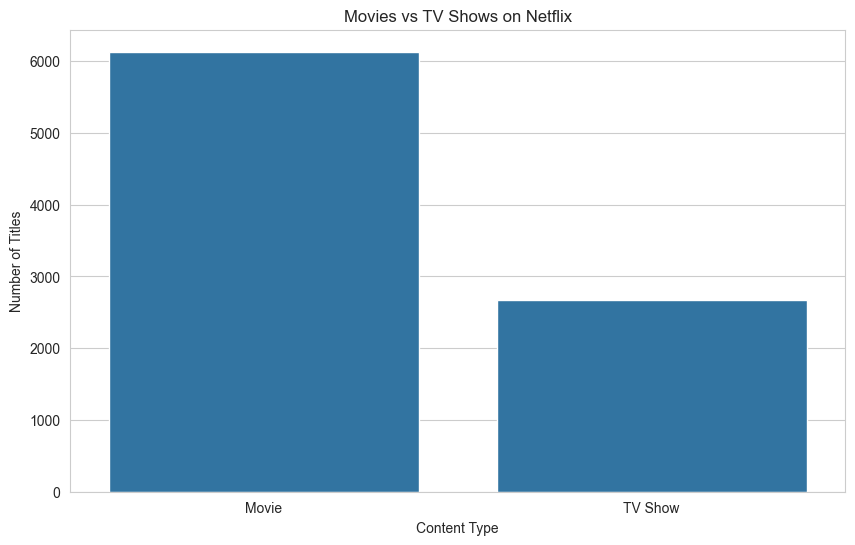

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [7]:
content_type_counts = df["type"].value_counts()

sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

content_type_counts

### Insight
Netflix has more **Movies** than **TV Shows**, suggesting that the platform relies heavily on movie content to maintain a broad and frequently refreshed catalog.

## 6. Genre Analysis
Because each title can belong to multiple genres, the `listed_in` column is split and expanded before counting the most common categories.

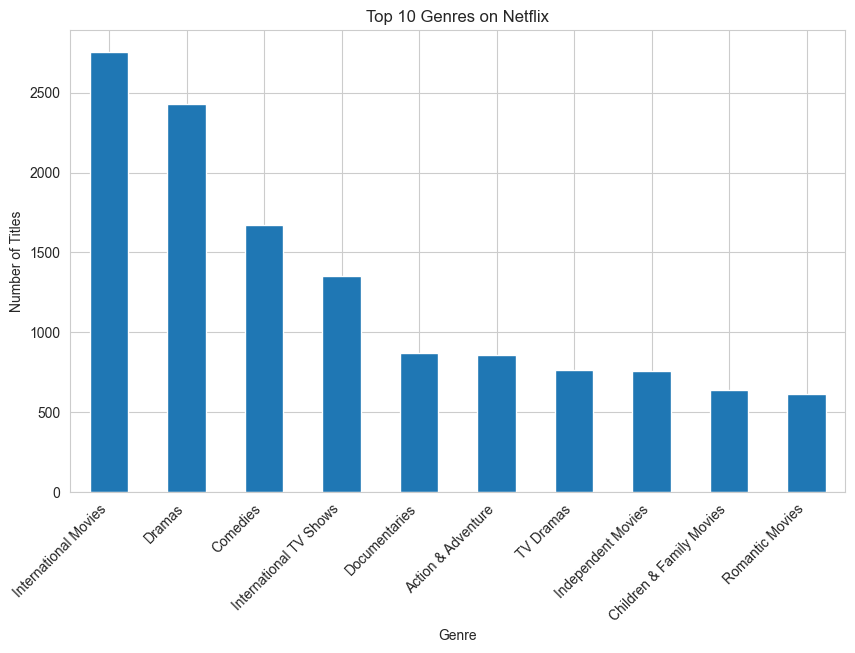

listed_in_clean
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [8]:
df_genres = df.explode("listed_in_clean")
genre_counts = df_genres["listed_in_clean"].value_counts().head(10)

genre_counts.plot(kind="bar")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.show()

genre_counts

### Insight
Genres such as **Drama**, **International Movies**, and **Comedies** appear most frequently, showing Netflix's emphasis on broad, globally appealing entertainment.

## 7. Content Growth Over Time
This analysis examines how the number of titles added to Netflix changed across years.

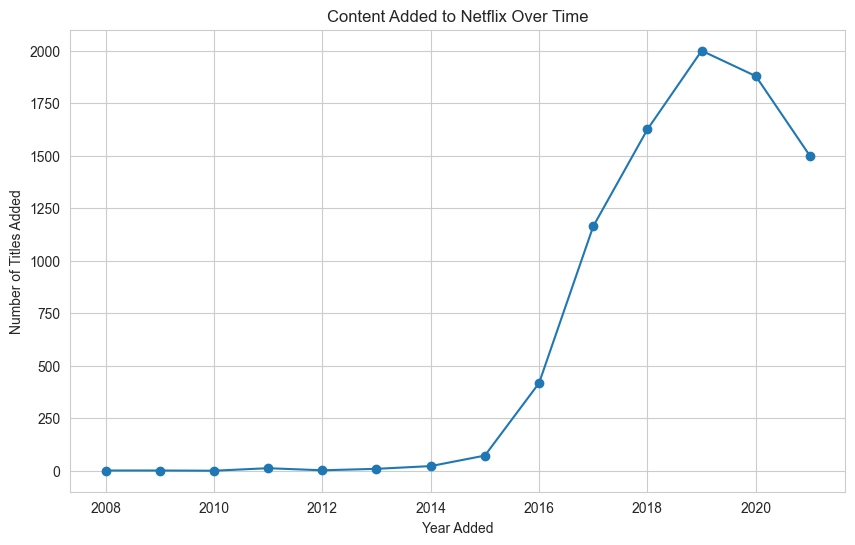

year_added
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

In [9]:
yearly_additions = df["year_added"].value_counts().sort_index()

yearly_additions.plot(kind="line", marker="o")
plt.title("Content Added to Netflix Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.show()

yearly_additions.tail(10)

### Insight
The number of titles added increased sharply after **2015**, which likely reflects Netflix's global expansion and accelerated investment in content acquisition and production.

## 8. Ratings Distribution
Ratings help us understand the type of audience Netflix content is primarily aimed at.

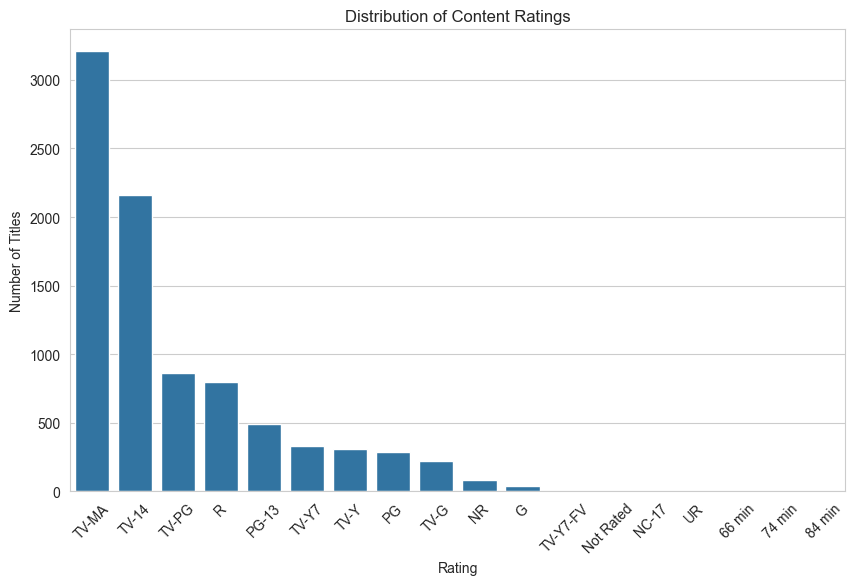

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

In [10]:
rating_order = df["rating"].value_counts().index

sns.countplot(data=df, x="rating", order=rating_order)
plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

df["rating"].value_counts().head(10)

### Insight
Ratings such as **TV-MA** and **TV-14** dominate the catalog, indicating that a large share of Netflix content is targeted toward teen and adult audiences rather than very young children.

## 9. Movie Duration Analysis
This section focuses only on movies to explore the most common movie lengths on the platform.

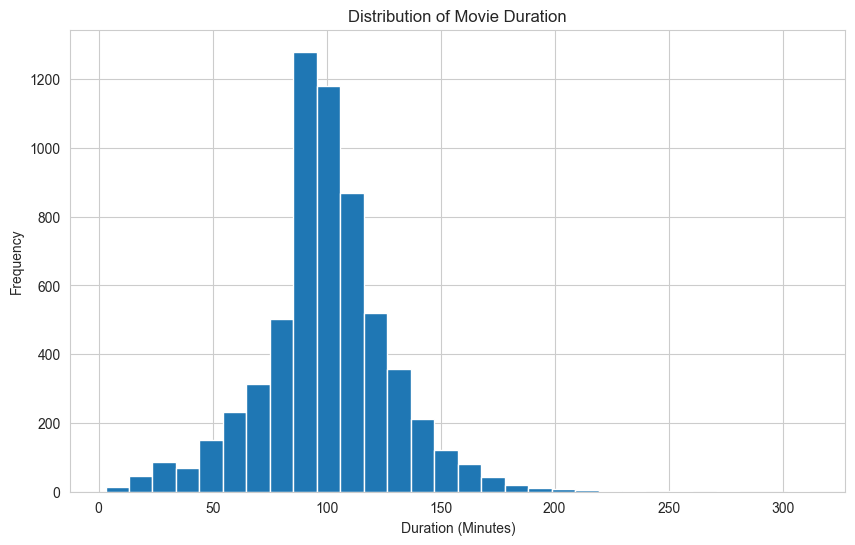

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

In [11]:
df_movies["duration_minutes"].dropna().hist(bins=30)
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")
plt.show()

df_movies["duration_minutes"].describe()

### Insight
Most Netflix movies cluster around **80 to 120 minutes**, which aligns with the standard runtime of feature-length films.

## 10. Top Countries Producing Netflix Content
This view highlights the countries most frequently represented in the dataset.

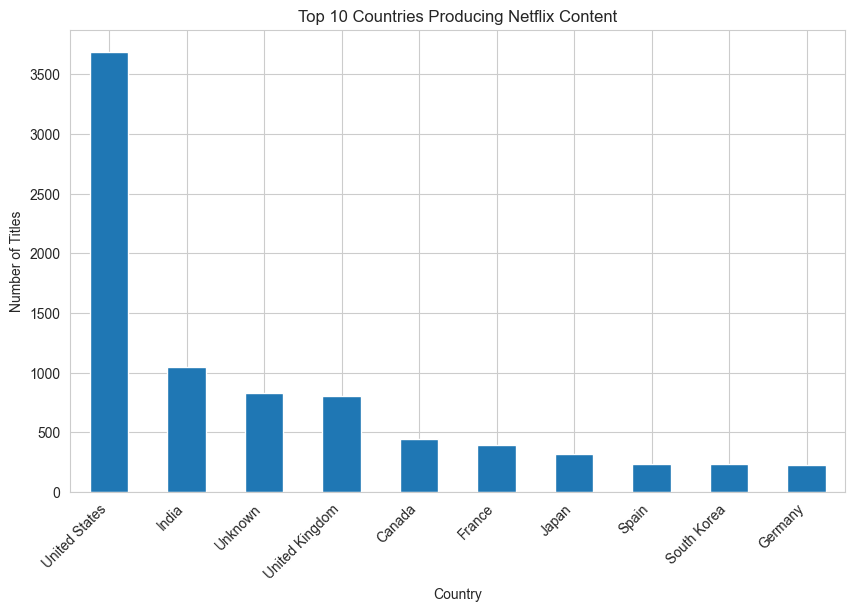

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

In [12]:
country_counts = (
    df.assign(country=df["country"].str.split(", "))
      .explode("country")
)

top_countries = (
    country_counts["country"]
    .str.strip()
    .replace("", np.nan)
    .dropna()
    .value_counts()
    .head(10)
)

top_countries.plot(kind="bar")
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.show()

top_countries

### Insight
The **United States** leads in content representation, while several other countries also contribute significantly, reflecting Netflix's increasingly international catalog strategy.

## 11. Final Conclusion

This analysis shows that:

- **Movies dominate** Netflix's catalog more than TV Shows.
- The platform saw **rapid content growth after 2015**.
- **Drama, International Movies, and Comedies** are among the most common genres.
- Ratings suggest a strong focus on **teen and adult audiences**.
- Most movies fall within the **standard 80–120 minute range**.
- The catalog reflects both **strong U.S. representation** and growing international diversity.

### Final Takeaway
This project demonstrates core data analyst skills:
- data cleaning,
- exploratory data analysis,
- visualization,
- and turning findings into business-focused insights.
